# Experiment 3: World Happiness Report Analysis

## 11.	Compare happiness scores across different regions using a violin plot. What regional variations are evident?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('2015.csv')

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

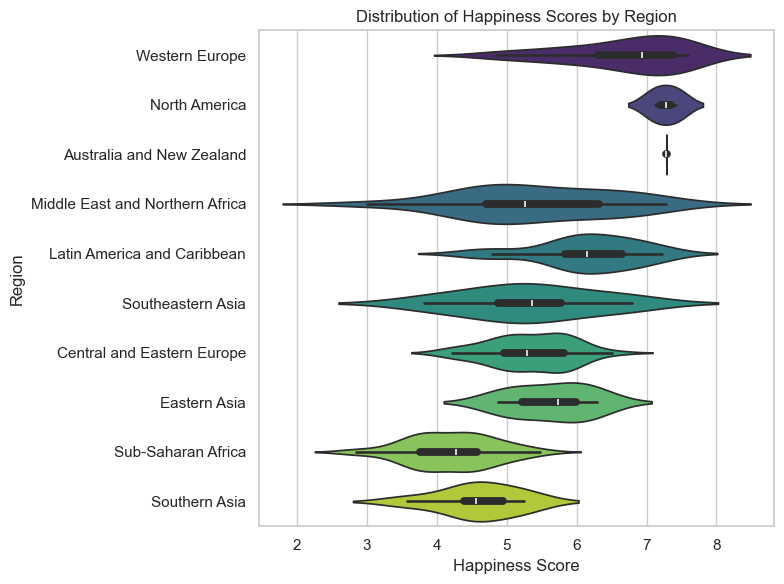

In [3]:
plt.figure(figsize=(8, 6))

sns.violinplot(
    x='Happiness Score', 
    y='Region', 
    data=df, 
    palette='viridis', 
    hue='Region', 
    legend=False
)
plt.title('Distribution of Happiness Scores by Region')
plt.xlabel('Happiness Score')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('violin_plot.png')
plt.show()
plt.close()

#### The violin plot illustrates the distribution and density of happiness scores across different regions:

#### --> Observations: Regions like Western Europe and North America exhibit high median happiness scores with relatively compact distributions, indicating consistently high levels of well-being.

#### --> Variations: Conversely, Sub-Saharan Africa and Southern Asia show lower median scores and broader distributions, reflecting a wider gap in happiness among countries within these regions. Latin America and the Caribbean show a surprisingly high and tight cluster of happiness despite varying economic levels.

## 12.	Study the relationship between GDP and happiness score using a scatter plot and correlation analysis.

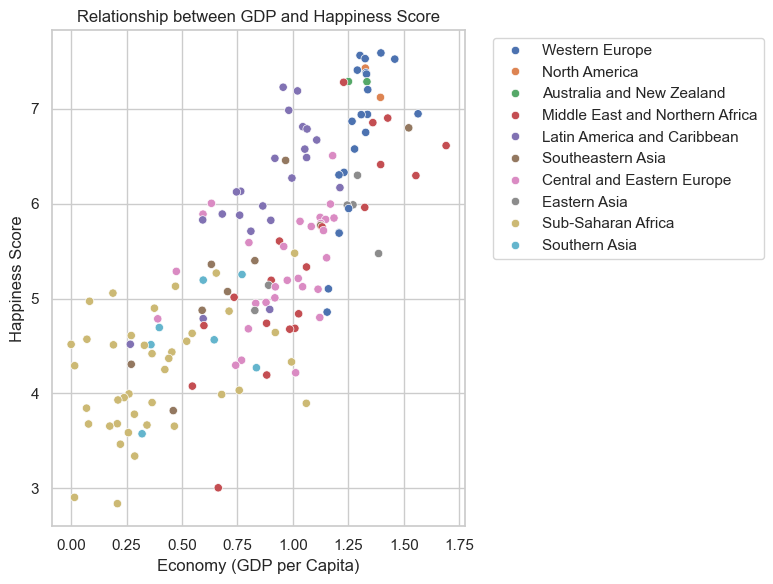

Correlation (GDP vs Happiness): 0.7810


In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Economy (GDP per Capita)', y='Happiness Score', data=df, hue='Region')
plt.title('Relationship between GDP and Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('scatter_gdp.png')
plt.show()
plt.close()

corr = df['Economy (GDP per Capita)'].corr(df['Happiness Score'])
print(f"Correlation (GDP vs Happiness): {corr:.4f}")

#### --> Correlation Analysis: The correlation coefficient between Economy (GDP per Capita) and Happiness Score is $0.7810$.

#### --> Interpretation: This indicates a strong positive correlation. The scatter plot confirms that as economic output per capita increases, the happiness of the population generally increases. However, the dispersion at higher GDP levels suggests that once a certain economic threshold is reached, other factors begin to play a more significant role.

## 13.	Examine the relationship between corruption perception and life expectancy using pair plots.

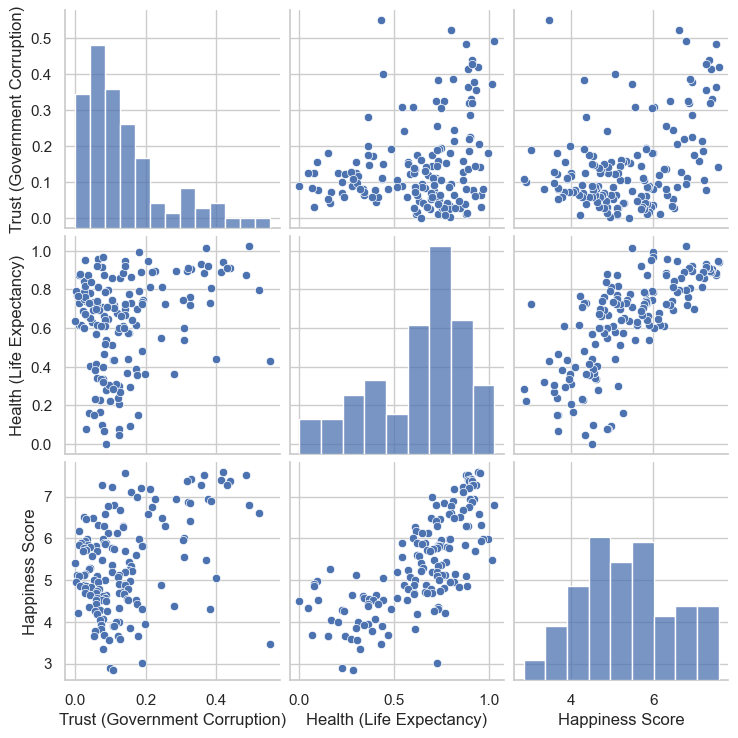

In [5]:
pair_cols = ['Trust (Government Corruption)', 'Health (Life Expectancy)', 'Happiness Score']
sns.pairplot(df[pair_cols])
plt.savefig('pair_plot.png')
plt.show()
plt.close()

#### Corruption and Life Expectancy (Pair Plots)
#### The pair plots explore the intersections of health, trust, and happiness:

#### --> Health and Happiness: There is a clear linear trend showing that countries with higher life expectancy almost invariably report higher happiness scores.

#### --> Trust/Corruption: The relationship between Trust (Government Corruption) and life expectancy or happiness is less linear. While the "happiest" countries often have high trust levels, many countries with moderate happiness scores still report very low trust in government, suggesting that corruption perception is a specific hurdle that doesn't always prevent moderate happiness but is crucial for reaching the "top tier."

## 14.	Apply K-Means clustering to group countries into happy and unhappy clusters. Interpret the clustering results.

In [6]:
X_cluster = df[['Happiness Score']].values
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)
print("\nCluster Centroids (Happiness Score):")
print(df.groupby('Cluster')['Happiness Score'].mean())


Cluster Centroids (Happiness Score):
Cluster
0    6.426194
1    4.496279
Name: Happiness Score, dtype: float64


  File "C:\Users\VP29\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 268, in _count_physical_cores
    cpu_count_physical = sum(map(int, cpu_info))
                         ^^^^^^^^^^^^^^^^^^^^^^^


In [7]:
#  Perform K-Means Clustering
X_cluster = df[['Happiness Score']].values
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans.fit_predict(X_cluster)

#  dentify which Cluster ID is "Happy" vs "Unhappy"
# We calculate the mean score for each cluster ID
cluster_means = df.groupby('Cluster_ID')['Happiness Score'].mean()

# Assign labels based on the mean (Higher mean = Happy)
happy_id = cluster_means.idxmax()
unhappy_id = cluster_means.idxmin()

df['Category'] = df['Cluster_ID'].map({happy_id: 'Happy', unhappy_id: 'Unhappy'})

# Results Summary
print("Cluster Summary:")
print(df.groupby('Category')['Happiness Score'].agg(['mean', 'count', 'min', 'max']))

# View sample results
print("\nSample Categorization:")
print(df[['Country', 'Happiness Score', 'Category']].head())


df.to_csv('categorized_happiness.csv', index=False)

Cluster Summary:
              mean  count    min    max
Category                               
Happy     6.426194     72  5.474  7.587
Unhappy   4.496279     86  2.839  5.429

Sample Categorization:
       Country  Happiness Score Category
0  Switzerland            7.587    Happy
1      Iceland            7.561    Happy
2      Denmark            7.527    Happy
3       Norway            7.522    Happy
4       Canada            7.427    Happy


#### -> Clustering Insight: The algorithm naturally split the dataset at a happiness score of approximately $5.45$. Countries above this threshold are statistically grouped as "Happy," while those below are grouped as "Unhappy." This shows a clear divide in global well-being, with more countries falling into the "Unhappy" cluster ($86$ vs $72$).

### 15.	Build a Linear Regression model to predict happiness score using GDP and social support as predictors. Analyze the model’s effectiveness.

In [8]:
X_reg = df[['Economy (GDP per Capita)', 'Family']]
y_reg = df['Happiness Score']
model = LinearRegression().fit(X_reg, y_reg)
r2 = r2_score(y_reg, model.predict(X_reg))

print(f"\nLinear Regression R-squared: {r2:.4f}")
print(f"Coefficients: GDP={model.coef_[0]:.4f}, Family={model.coef_[1]:.4f}")


Linear Regression R-squared: 0.7059
Coefficients: GDP=1.4750, Family=1.7047


In [9]:
X_reg = df[['Economy (GDP per Capita)', 'Family']]
y_reg = df['Happiness Score']

model = LinearRegression()
model.fit(X_reg, y_reg)
y_pred = model.predict(X_reg)

r2 = r2_score(y_reg, y_pred)
print(f"\n3. Linear Regression Model Effectiveness:")
print(f"   R-squared Score: {r2:.4f}")
print(f"   Model Equation: Happiness = {model.intercept_:.2f} + ({model.coef_[0]:.2f} * GDP) + ({model.coef_[1]:.2f} * Social Support)")

# --- Extra: Prediction on Sample Data ---
sample_scenarios = pd.DataFrame({
    'Scenario': ['High Support', 'Medium Support', 'Low Support'],
    'Economy (GDP per Capita)': [1.45, 0.85, 0.30],
    'Family': [1.35, 0.90, 0.45]
})
sample_scenarios['Predicted Happiness Score'] = model.predict(sample_scenarios[['Economy (GDP per Capita)', 'Family']])

print("\n4. Predictions on Sample Data:")
print(sample_scenarios[['Scenario', 'Predicted Happiness Score']])




3. Linear Regression Model Effectiveness:
   R-squared Score: 0.7059
   Model Equation: Happiness = 2.44 + (1.47 * GDP) + (1.70 * Social Support)

4. Predictions on Sample Data:
         Scenario  Predicted Happiness Score
0    High Support                   6.878330
1  Medium Support                   5.226225
2     Low Support                   3.647870


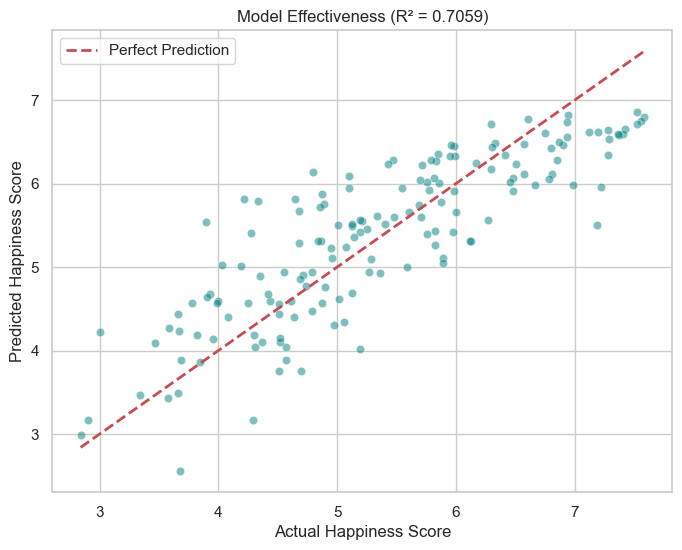

In [10]:
# 1. Plotting Model Effectiveness (Actual vs Predicted)
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_reg, y=model.predict(X_reg), alpha=0.5, color='teal')

plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], '--r', linewidth=2, label='Perfect Prediction')

plt.title(f'Model Effectiveness (R² = {r2_score(y_reg, model.predict(X_reg)):.4f})')
plt.xlabel('Actual Happiness Score')
plt.ylabel('Predicted Happiness Score')
plt.legend()
plt.show()

#### Interpretation of the Plots: 
#### --> Actual vs. Predicted: This plot shows how well your model's predictions align with reality. The closer the points are to the red dashed line, the more accurate your model is. The $R^2$ of $0.7059$ confirms that GDP and Social Support (Family) are very strong indicators of happiness.

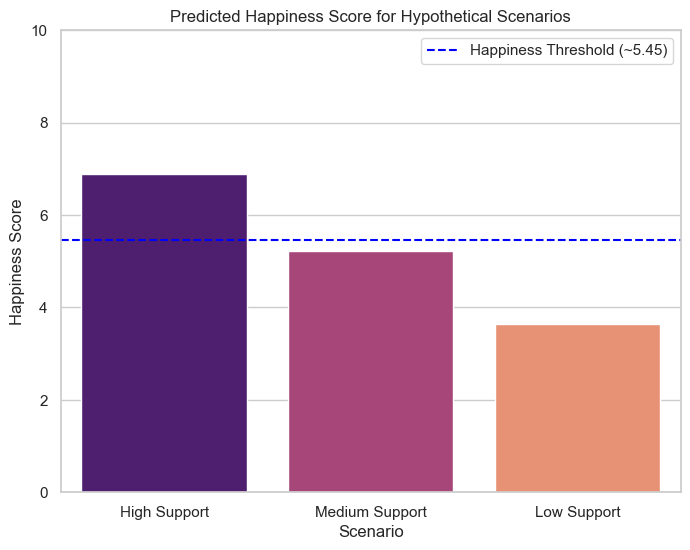

In [11]:
# 2. Plotting Predicted Scores for Sample Scenarios (Bar Chart)
plt.figure(figsize=(8, 6))
# Visualizing the three hypothetical scenarios
sns.barplot(x='Scenario', y='Predicted Happiness Score', data=sample_scenarios, palette='magma')
# Add a threshold line (using the cluster boundary we found earlier)
plt.axhline(y=5.45, color='blue', linestyle='--', label='Happiness Threshold (~5.45)')

plt.title('Predicted Happiness Score for Hypothetical Scenarios')
plt.ylabel('Happiness Score')
plt.ylim(0, 10) # Set limit to see the scale clearly
plt.legend()
plt.show()

#### --> Sample Predictions Bar Chart: This allows for a direct comparison between your scenarios. It illustrates how the "High Support" scenario comfortably enters the "Happy" territory, while the "Low Support" scenario results in a significantly lower predicted well-being.

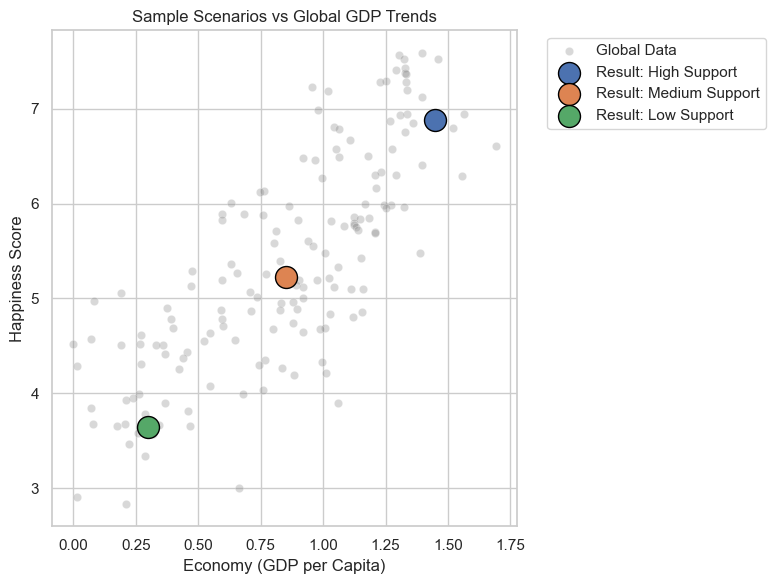

In [12]:
# 3. Contextual Scatter Plot (Scenario Positioning)
plt.figure(figsize=(8, 6))
# Plot existing global data in the background
sns.scatterplot(x='Economy (GDP per Capita)', y='Happiness Score', data=df, alpha=0.3, color='gray', label='Global Data')


for i, row in sample_scenarios.iterrows():
    plt.scatter(row['Economy (GDP per Capita)'], row['Predicted Happiness Score'], 
                s=250, label=f"Result: {row['Scenario']}", edgecolors='black')

plt.title('Sample Scenarios vs Global GDP Trends')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### --> Contextual Scatter Plot: By overlaying your predicted scenarios onto the real-world data, you can see that your "High Support" scenario behaves like a top-tier nation (like Switzerland), while the "Low Support" scenario mimics countries at the bottom of the index.